# MHealth Data: ECG Signal EDA

## Table of Contents

0. Import Libraries & Data
1. Contextual Information
2. Preliminary EDA & Visualizations

In [1]:
%pip install -r requirements.txt


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import csv
import sqlite3
import pandas as pd
import numpy as np
import math
import sklearn
import os
from pathlib import Path
import sys
sys.path.append('../')
from scripts.initiate_database import get_connection
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import classification_report
import scipy
from scipy import signal
import sqlite3
import mpl_toolkits
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
from matplotlib import animation
from scipy.signal import find_peaks, butter, filtfilt
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['animation.embed_limit'] = 50

Let's connect to the database and access the data description and general information.

In [3]:
#DB_FILE = "/Users/jaeahkim/Google Drive/My Drive/Personal Projects/FitnessRecommender/data/raw/mHealth.db"

conn = get_connection()
df = pd.read_sql("SELECT * FROM sensor_data ORDER BY subject_id ASC", conn)
conn.close()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211745 entries, 0 to 1211744
Data columns (total 26 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1211745 non-null  int64  
 1   subject_id        1211745 non-null  int64  
 2   x_accel_chest     1211745 non-null  float64
 3   y_accel_chest     1211745 non-null  float64
 4   z_accel_chest     1211745 non-null  float64
 5   ecg_l1            1211745 non-null  float64
 6   ecg_l2            1211745 non-null  float64
 7   x_accel_l_ankle   1211745 non-null  float64
 8   y_accel_l_ankle   1211745 non-null  float64
 9   z_accel_l_ankle   1211745 non-null  float64
 10  x_gyro_l_ankle    1211745 non-null  float64
 11  y_gyro_l_ankle    1211745 non-null  float64
 12  z_gyro_l_ankle    1211745 non-null  float64
 13  x_magnet_l_ankle  1211745 non-null  float64
 14  y_magnet_l_ankle  1211745 non-null  float64
 15  z_magnet_l_ankle  1211745 non-null  float64
 16  x_accel_r_a

There are a total of 1,211,745 entries in the dataset, for a total of 10 research subjects. There are no null values.

## 1. Contextual Information

The dataset contains over a million rows of sensor information. It is important to be able to know how to interpret the sensor data values. I refer to the dataset documentation for a lot of this section, as well as some auxiliary online research.

### Experimental Set Up  

The dataset comprises of body motion and vital (namely ECG) sign recordings for ten volunteers of diverse profile. These ten volunteers performed 12 physical activities, labeled in the dataset as follows. Each activity was done for 1 minute, except for activities 6, 7, 8, and 12. Those activities were carried out as 20 reps per activity.

| **Label** |        **Activity**       |
|:---------:|:-------------------------:|
|     0     |       Null Class      |
|     1     |       Standing Still      |
|     2     |    Sitting and Relaxing   |
|     3     |         Lying Down        |
|     4     |          Walking          |
|     5     |      Climbing Stairs      |
|     6     |    Waist Bends Forward    |
|     7     | Frontal Elevation of Arms |
|     8     | Knees Bending (Crouching) |
|     9     |          Cycling          |
|     10    |          Jogging          |
|     11    |          Running          |
|     12    |   Jump (Front and Back)   |

Shimmer2 [BUR10] wearable sensors were used for all of the recordings. The sensors were placed on the subject's chest, right wrist, and left ankle.

The sensor positioned on the chest also provides 2-lead ECG measurements, which was not used for the development of the recognition model in the original publication, but will be used for model training in this project. 

All sensor modalities were recorded at a sampling rate of 50Hz, meaning a 5-second window is 250 rows. The activities were collected in an out-of-lab environment with no constraints on the execution of activities, with the exception that the subject should try their best. 

Units are in m/s^2 for acceleration, deg/s for gyroscope, local µT for magnetometer, and mV for ECG data. 


### The Variables and How to Interpret Them

#### ECG Data

Sources: 
https://geekymedics.com/understanding-an-ecg/

Whenever the direction of electrical activity moves towards a lead, a positive deflection is produced. As such, whenever the direction of electrical activity moves away from a lead, a negative deflection is produced. Lead 2 shows the most positive deflection as it is the most closely aligned to the overall direction of electrical spread (Reference: https://geekymedics.com/wp-content/uploads/2023/10/Normal-Cardiac-Axis-600x338.jpg). Both L1 and L2 data will be used in the development of the model. 

## 2. Preliminary EDA & Visualizations

Let's look at the subject ID values.

In [4]:
df.subject_id.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Note: Keep in mind that subject IDs are zero-indexed in the database. That is, subject 1's subject ID is 0.

How about the distribution of subject ID value counts? Are there any subjects who have significantly more data than others?

In [5]:
df.subject_id.value_counts().sort_index()

subject_id
0    161280
1    130561
2    122112
3    116736
4    118808
5     98304
6    104448
7    129024
8    134168
9     96304
Name: count, dtype: int64

Subjects 5 and 9 have noticeably less data points than the rest of the subjects in the dataset. This doesn't necessarily mean that this is an imbalanced dataset, unless the data values for the activity label (the variable of interest) is imbalanced. Let's check this:

In [6]:
df.activity_label.value_counts().sort_index()

activity_label
0     869180
1      30720
2      30489
3      30720
4      30720
5      30720
6      27916
7      29441
8      29337
9      30720
10     30720
11     30720
12     10342
Name: count, dtype: int64

There are more than 20x the amount of data points for activity label 0 than for activities 1-11. Activity 12 has the least amount of data points; only 10,342. 

According to the MHealth Dataset documentation, the label is 0 for the null class. Let's see what this means:

In [7]:
# The motion, magnetometer, and gyroscope data for the null class:
df[df['activity_label'] == 0].head()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
0,1,0,-9.8184,0.009971,0.29563,0.004186,0.004186,2.1849,-9.6967,0.63077,...,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,-2.35000,-1.610200,-0.030899,0
1,2,0,-9.8489,0.524040,0.37348,0.004186,0.016745,2.3876,-9.5080,0.68389,...,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,-2.16320,-0.882540,0.326570,0
2,3,0,-9.6602,0.181850,0.43742,0.016745,0.037677,2.4086,-9.5674,0.68113,...,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,-1.61750,-0.165620,-0.030693,0
3,4,0,-9.6507,0.214220,0.24033,0.079540,0.117220,2.1814,-9.4301,0.55031,...,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,-1.07710,0.006945,-0.382620,0
4,5,0,-9.7030,0.303890,0.31156,0.221870,0.205130,2.4173,-9.3889,0.71098,...,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,-0.53684,0.175900,-1.095500,0


In [8]:
# The motion, magnetometer, and gyroscope data for activity 11 (running):
df[df['activity_label'] == 11].head()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
98816,98817,0,-6.8405,1.1151,0.8372,-0.69492,-1.7206,-3.95080,-19.1540,12.2940,...,-19.67000,1.2327,-3.73000,-0.78431,-0.48665,0.58405,6.0901,124.2700,73.969,11
98817,98818,0,-2.3256,1.6357,1.7788,-0.68655,-1.4108,9.41860,-11.6420,-15.6960,...,-13.87000,6.6378,0.77981,-0.78431,-0.48665,0.58405,21.9650,95.9980,111.750,11
98818,98819,0,5.1427,3.9738,1.7050,-1.84200,-2.4113,19.52100,-6.9617,-12.0070,...,-9.19500,11.6860,3.60510,-0.78431,-0.48665,0.58405,38.3520,47.0350,132.070,11
98819,98820,0,7.7713,4.3640,-3.3757,-2.49500,-3.2988,-2.53520,-9.3031,-1.5947,...,-5.13840,14.9990,3.94790,-0.94510,-0.35729,0.38578,41.3690,7.6148,149.490,11
98820,98821,0,5.0924,5.9866,-7.7138,-1.92990,-3.7300,0.75023,-19.1470,11.9980,...,-0.97921,15.0400,4.96030,-0.94510,-0.35729,0.38578,40.4200,2.5166,165.040,11


### The Null Class Problem

There are large differences between the values shown above. There are several implications for this project: 

1. Class Imbalance: The biggest effect of this "null class", which makes up a very big percentage of the total data. I need to be cautious in emphasizing not letting the model train on this data, and preprocess so that it can be treated as "noise" or kind of "nothing" data. If not, the model will probably get very good at predicting "doing nothing" based on sheer probability.
2. High Variance/Unpredictability: Unlike rhythmic activities such as running or climbing stairs, the null class is chaotic. That is, because there is no defined activity, it can range from staying perfectly still, to erratic fidgeting or leg shaking. 
3. False Exertion: The goal of the model is to be able to predict the exertion level of the user based on sensor data. If subjects in the null class are fidgeting or moving the sensor, the vector magnitude of the accelerometers may spike. I need to take the appropriate measures such that the model doesn't mistakenly label these activities as high exertion levels. This is where the ECG data is important to incorporate into the model.

How can the class imbalance be addressed? There are a few options to pursue at this point: 
- Drop the null class. This option is useful if the focus is purely on fitness mapping, as the model can train and predict only on known exertion types.
- Keep the null class, but treat it as baseline exertion (e.g. level 0 exertion). This is probably a more realistic approach because the user isn't always working out, but more difficult because the user's specific activity is not known nor controlled.
- Use the ECG data to validate the null class. If the activity label is 0 but the ECG HR data is high, that's a likely "recovery period". If the HR is low, then it could be considered as a true idle. 

Let's try to understand how the null class behaves and varies as compared to a low exertion level activity (such as standing still: 1) and a high exertion level activity (such as running: 11). 

In [9]:
# Null class
null_class = df[df['activity_label'] == 0].copy()
null_class.describe()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
count,8.691800e+05,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,...,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.0
mean,5.994429e+05,4.188982,-8.932388,-0.244002,-1.097303,-0.008574,-0.003196,1.372589,-9.942858,-1.057254,...,-3.816227,-5.810996,2.402283,-0.307129,-0.486630,0.221647,0.446673,0.434293,-0.521577,0.0
std,3.524990e+05,2.967277,3.116112,1.813535,3.070122,0.707794,0.669674,3.656883,3.659095,5.016011,...,4.232406,5.405107,3.753359,0.515701,0.557882,0.577047,23.077390,34.646803,63.758268,0.0
min,1.000000e+00,0.000000,-22.306000,-20.158000,-18.391000,-8.619600,-8.619600,-22.126000,-19.613000,-19.364000,...,-22.361000,-18.972000,-18.239000,-8.339200,-3.570800,-2.689700,-317.930000,-363.900000,-717.550000,0.0
25%,2.880018e+05,1.000000,-9.843300,-1.266800,-2.603300,-0.246990,-0.196760,0.130430,-10.252000,-2.434100,...,-6.369400,-9.338700,0.129900,-0.713730,-0.926080,-0.303880,-6.205825,-10.466000,-15.054000,0.0
50%,6.068795e+05,4.000000,-9.398600,-0.374770,-0.865480,-0.071167,-0.041863,1.290100,-9.695800,-0.119300,...,-3.185600,-7.340300,1.980000,-0.378430,-0.648870,0.252160,0.368205,0.348010,-0.589615,0.0
75%,9.090642e+05,7.000000,-8.199900,0.632450,0.599853,0.159080,0.154890,2.472700,-9.233600,1.093700,...,-1.438800,-2.602900,4.791700,0.045098,-0.133470,0.741380,7.311300,10.758000,14.189250,0.0
max,1.211745e+06,9.000000,19.078000,20.917000,25.534000,8.514900,8.519100,20.054000,21.059000,24.773000,...,19.864000,22.191000,25.735000,3.319600,1.556500,2.750000,251.150000,337.760000,656.860000,0.0


In [10]:
# Low exertion level class: standing still (1)
standing_class = df[df['activity_label'] == 1].copy()
standing_class.describe()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
count,3.072000e+04,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,...,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.0
mean,5.947317e+05,4.500000,-9.613480,-0.699418,0.141333,0.014754,-0.000798,0.880712,-9.692594,1.090515,...,-2.440308,-9.303726,1.139256,-0.340318,-0.746303,0.172305,0.355636,0.344874,-0.553059,1.0
std,3.440065e+05,2.872328,0.246040,0.660306,1.394403,0.463791,0.317936,0.951944,0.135990,0.574736,...,0.750628,0.250751,0.959020,0.472812,0.227104,0.455742,0.770587,1.793016,1.128690,0.0
min,6.657000e+03,0.000000,-10.951000,-2.597100,-2.654700,-1.595000,-1.276800,-1.806400,-10.584000,-1.016600,...,-4.876400,-10.438000,-1.616100,-0.907840,-1.110900,-0.543100,-9.893800,-30.916000,-14.096000,1.0
25%,2.979858e+05,2.000000,-9.769800,-1.172300,-0.609208,-0.142330,-0.117220,0.310645,-9.785100,0.567005,...,-3.008800,-9.492125,0.347485,-0.803920,-0.932240,-0.234910,0.170440,-0.019806,-1.077500,1.0
50%,5.942015e+05,4.500000,-9.659500,-0.829715,-0.104840,-0.071167,-0.041863,0.898125,-9.696200,1.065700,...,-2.652650,-9.316450,1.248850,-0.349020,-0.737165,0.161640,0.362660,0.354020,-0.707520,1.0
75%,8.630012e+05,7.000000,-9.518375,-0.101852,0.823525,0.037677,0.037677,1.568600,-9.602000,1.546725,...,-2.195800,-9.100100,1.799325,0.056863,-0.650920,0.418100,0.551180,0.887550,0.000103,1.0
max,1.149233e+06,9.000000,-8.419300,0.949660,4.296100,4.902100,3.457900,2.815100,-8.660900,3.218000,...,1.677700,-8.590800,3.242500,0.460780,-0.184800,0.995690,19.097000,57.527000,19.288000,1.0


In [11]:
# High exertion level class: running (11)
running_class = df[df['activity_label'] == 11].copy()
running_class.describe()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
count,3.072000e+04,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,...,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.0
mean,6.626533e+05,4.500000,-7.481828,0.002838,-2.481333,-0.142393,-0.204459,3.629201,-12.291468,-3.443592,...,-7.672636,-4.719071,-0.666658,-0.534553,-0.032328,0.708951,-4.902108,14.126681,3.051872,11.0
std,3.407643e+05,2.872328,10.167910,5.045527,4.822459,1.739136,1.975032,9.174321,9.061575,11.692899,...,11.250424,11.765866,6.965302,0.301443,0.394119,0.473876,76.038963,60.440475,213.977805,0.0
min,9.881700e+04,0.000000,-22.438000,-20.188000,-18.392000,-8.619600,-8.619600,-22.146000,-19.619000,-19.373000,...,-22.015000,-18.972000,-18.238000,-1.111800,-1.141700,-0.924570,-319.030000,-354.420000,-702.570000,11.0
25%,3.660818e+05,2.000000,-19.065000,-3.023275,-4.588300,-0.703300,-0.556780,-0.824580,-19.187000,-15.068500,...,-20.594000,-15.539250,-4.630100,-0.764710,-0.227930,0.646550,-58.570750,-18.758500,-137.212500,11.0
50%,6.494975e+05,4.500000,-4.384950,-0.167305,-1.692200,-0.104660,-0.050235,3.701000,-16.470500,-3.497650,...,-7.779650,-7.544100,-0.875145,-0.564710,-0.006160,0.890090,-4.149050,13.906500,-8.124200,11.0
75%,9.674492e+05,7.000000,1.348200,2.885200,0.312652,0.468860,0.498170,8.862600,-7.227675,5.566950,...,0.810540,6.271175,3.107950,-0.339220,0.195070,1.010800,48.850750,49.436500,148.185000,11.0
max,1.198921e+06,9.000000,12.996000,20.927000,24.991000,8.506500,8.519100,20.024000,21.161000,25.015000,...,19.787000,21.865000,24.639000,0.613730,1.121100,1.185300,239.690000,331.910000,657.180000,11.0


The null class has a high standard deviation, but not as high as the high exertion level class. However, the null class' averages are closer to the low exertion level activity. 

What I could do is to combine options 2 and 3, and keep the null class and treat it as a level 0, baseline exertion (i.e. the user is not working out), and at the same time, use the ECG HR data to validate the null class. For example, if the sensor data and HR is high, the exertion could be classified as "recovery". 

Essentially, the idea is to combine sensor intensity with physiological data (heart rate) to differentiate between active movement, rest, and physiological stress, and generally categorize the null class into four groups:

| **Motion Intensity (accel)** | **Heart Rate** | **Classification** |                               **Logic**                              |
|:----------------------------:|:--------------:|:------------------:|:--------------------------------------------------------------------:|
|              Low             |       Low      |   Baseline (Idle)  |                 True Null: Sitting or standing still.                |
|             High             |       Low      |    Sensor Noise    |       False Exertion: Moving the sensor, but no cardio load.       |
|              Low             |      High      |      Recovery      | Afterburn: Heart rate is still high, but movement has stopped. |
|             High             |      High      |   Active Exertion  |           True Workout: Validates the High Exertion class.           |

Perhaps I could use the high motion intensity, high heart rate subgroup of the null class for model evaluation (in the validation phase). This will be further explored and addressed in section 6: Data Preprocessing. But for now, let's see how we can define our thresholds for the above subgroups.

Firstly, the heart rate threshold will be 100bpm, which is the upper boundary for a normal resting heart rate. Any heart rate values at or above 100bpm will be considered a high heart rate (for the purposes of this project). 

The motion intensity threshold is less straightforward. The definition of the threshold would depend on whether I want the eventual recommender system to be subject-dependent or subject-independent. The following are some pros and cons of each approach:

Subject-dependent:
- Pros: Highly accurate for the individual. Normalizes for differences in body movement style. 
- Cons: Doesn't scale. If a new user starts using the recommender system, the model won't know their specific threshold until it collects days worth of data. 

Subject-independent:
- Pros: Creates a "general" model that can predict exertion for a random person/stranger.
- Cons: Very noisy. Individual variations may "wash out" the signal, which is more so probable given that the volunteer subjects are of diverse build. 

For now, I will calculate thresholds on a subject-dependent basis in section 6. The development of a subject-independent model could be the next step. 

In [12]:
corr = df.corr()

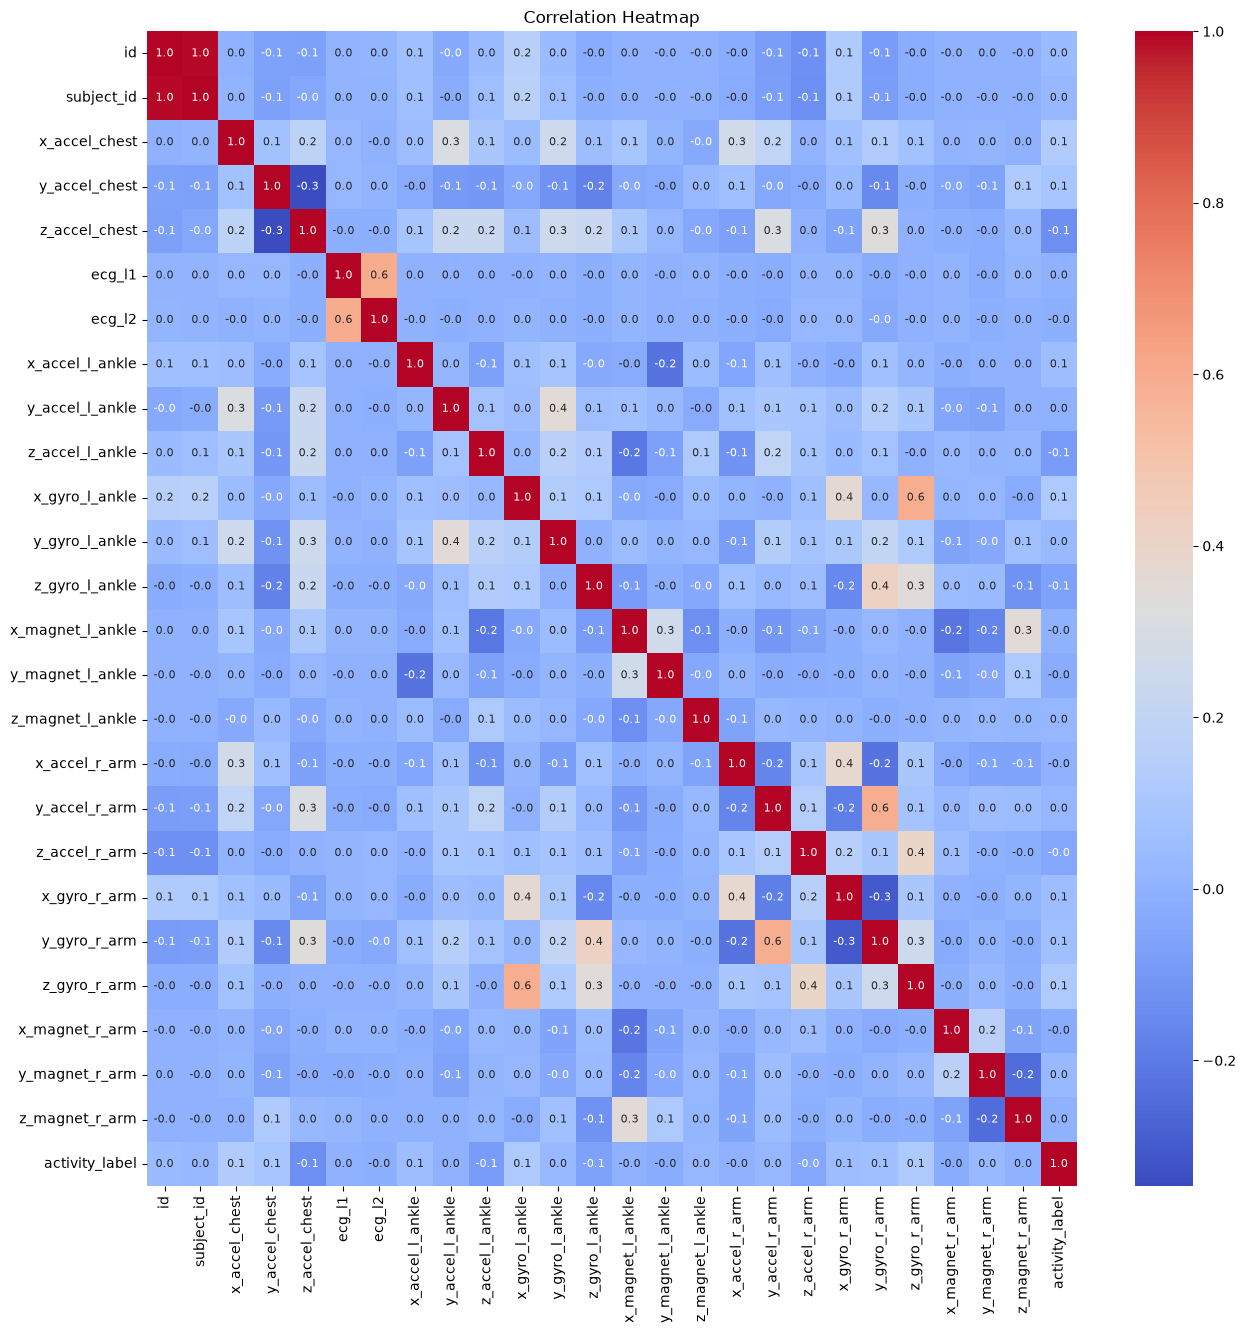

In [13]:
# Plot the correlation matrix
plt.figure(figsize = (15, 15))
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".1f", annot_kws = {"size": 8})
plt.title("Correlation Heatmap")
plt.show()

Interestingly, most of the variables are not strongly correlated with each other. Arm gyro data is moderately positively correlated with arm acceleration data. ECG data is not correlated with any other variables, which I guess makes sense because ECG data is rhythmic/cyclical and there is probably a time lag between ECG data and acceleration/gyro data. 

#### Subject Focus: Subject 1

Let's look at one subject first: subject 1. We will be looking at activity 11 (running) and specifically at the x acceleration of the chest motion sensor.

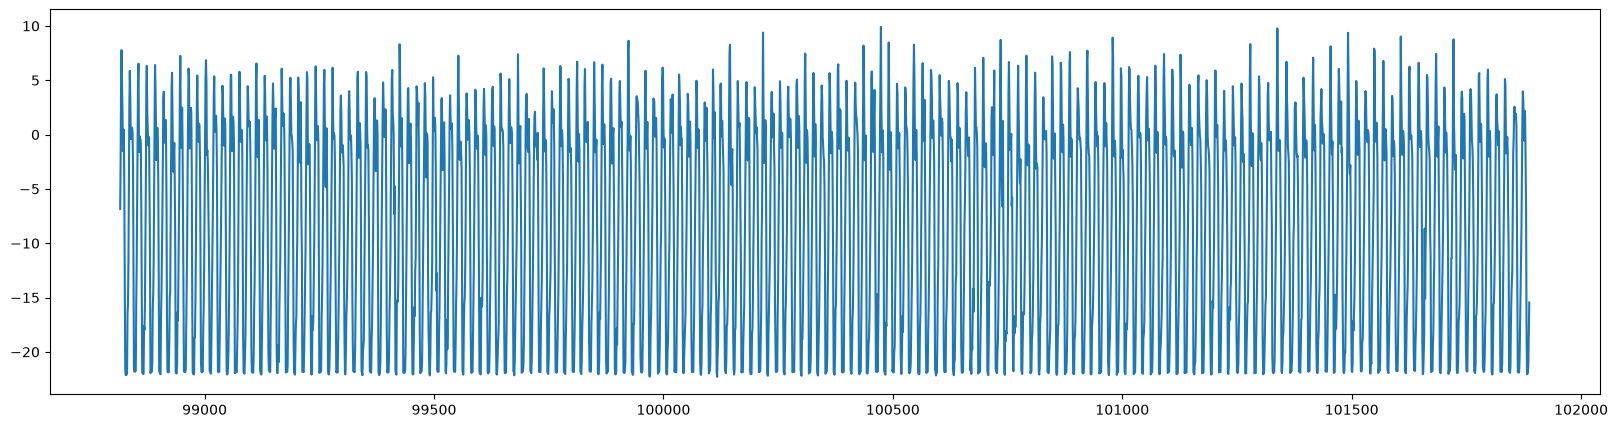

In [14]:
subject1_df = df[df["subject_id"] == 0].copy()

plt.figure(figsize = (20, 5))
plt.plot(subject1_df[subject1_df["activity_label"] == 11]["x_accel_chest"])
plt.show()

The x acceleration seems periodic, which aligns with intuition. 

It may be valuable to see how the data clusters for low intensity activities vs. high intensity activities. The following plots show each measurement's relative distributions.

In [17]:
# Define data groups dictionary
data_groups = {
    "chest_acceleration": [
        "x_accel_chest",
        "y_accel_chest",
        "z_accel_chest"
    ],
    "ecg": [
        "ecg_l1",
        "ecg_l2"
    ],
    "ankle_acceleration": [
        "x_accel_l_ankle",
        "y_accel_l_ankle",
        "z_accel_l_ankle"
    ],
    "ankle_gyro": [
        "x_gyro_l_ankle",
        "y_gyro_l_ankle",
        "z_gyro_l_ankle"
    ],
    "ankle_magnet": [
        "x_magnet_l_ankle",
        "y_magnet_l_ankle",
        "z_magnet_l_ankle"
    ],
    "arm_acceleration": [
        "x_accel_r_arm",
        "y_accel_r_arm",
        "z_accel_r_arm"
    ],
    "arm_gyro": [
        "x_gyro_r_arm",
        "y_gyro_r_arm",
        "z_gyro_r_arm"
    ],
    "arm_magnet": [
        "x_magnet_r_arm",
        "y_magnet_r_arm",
        "z_magnet_r_arm"
    ]
}

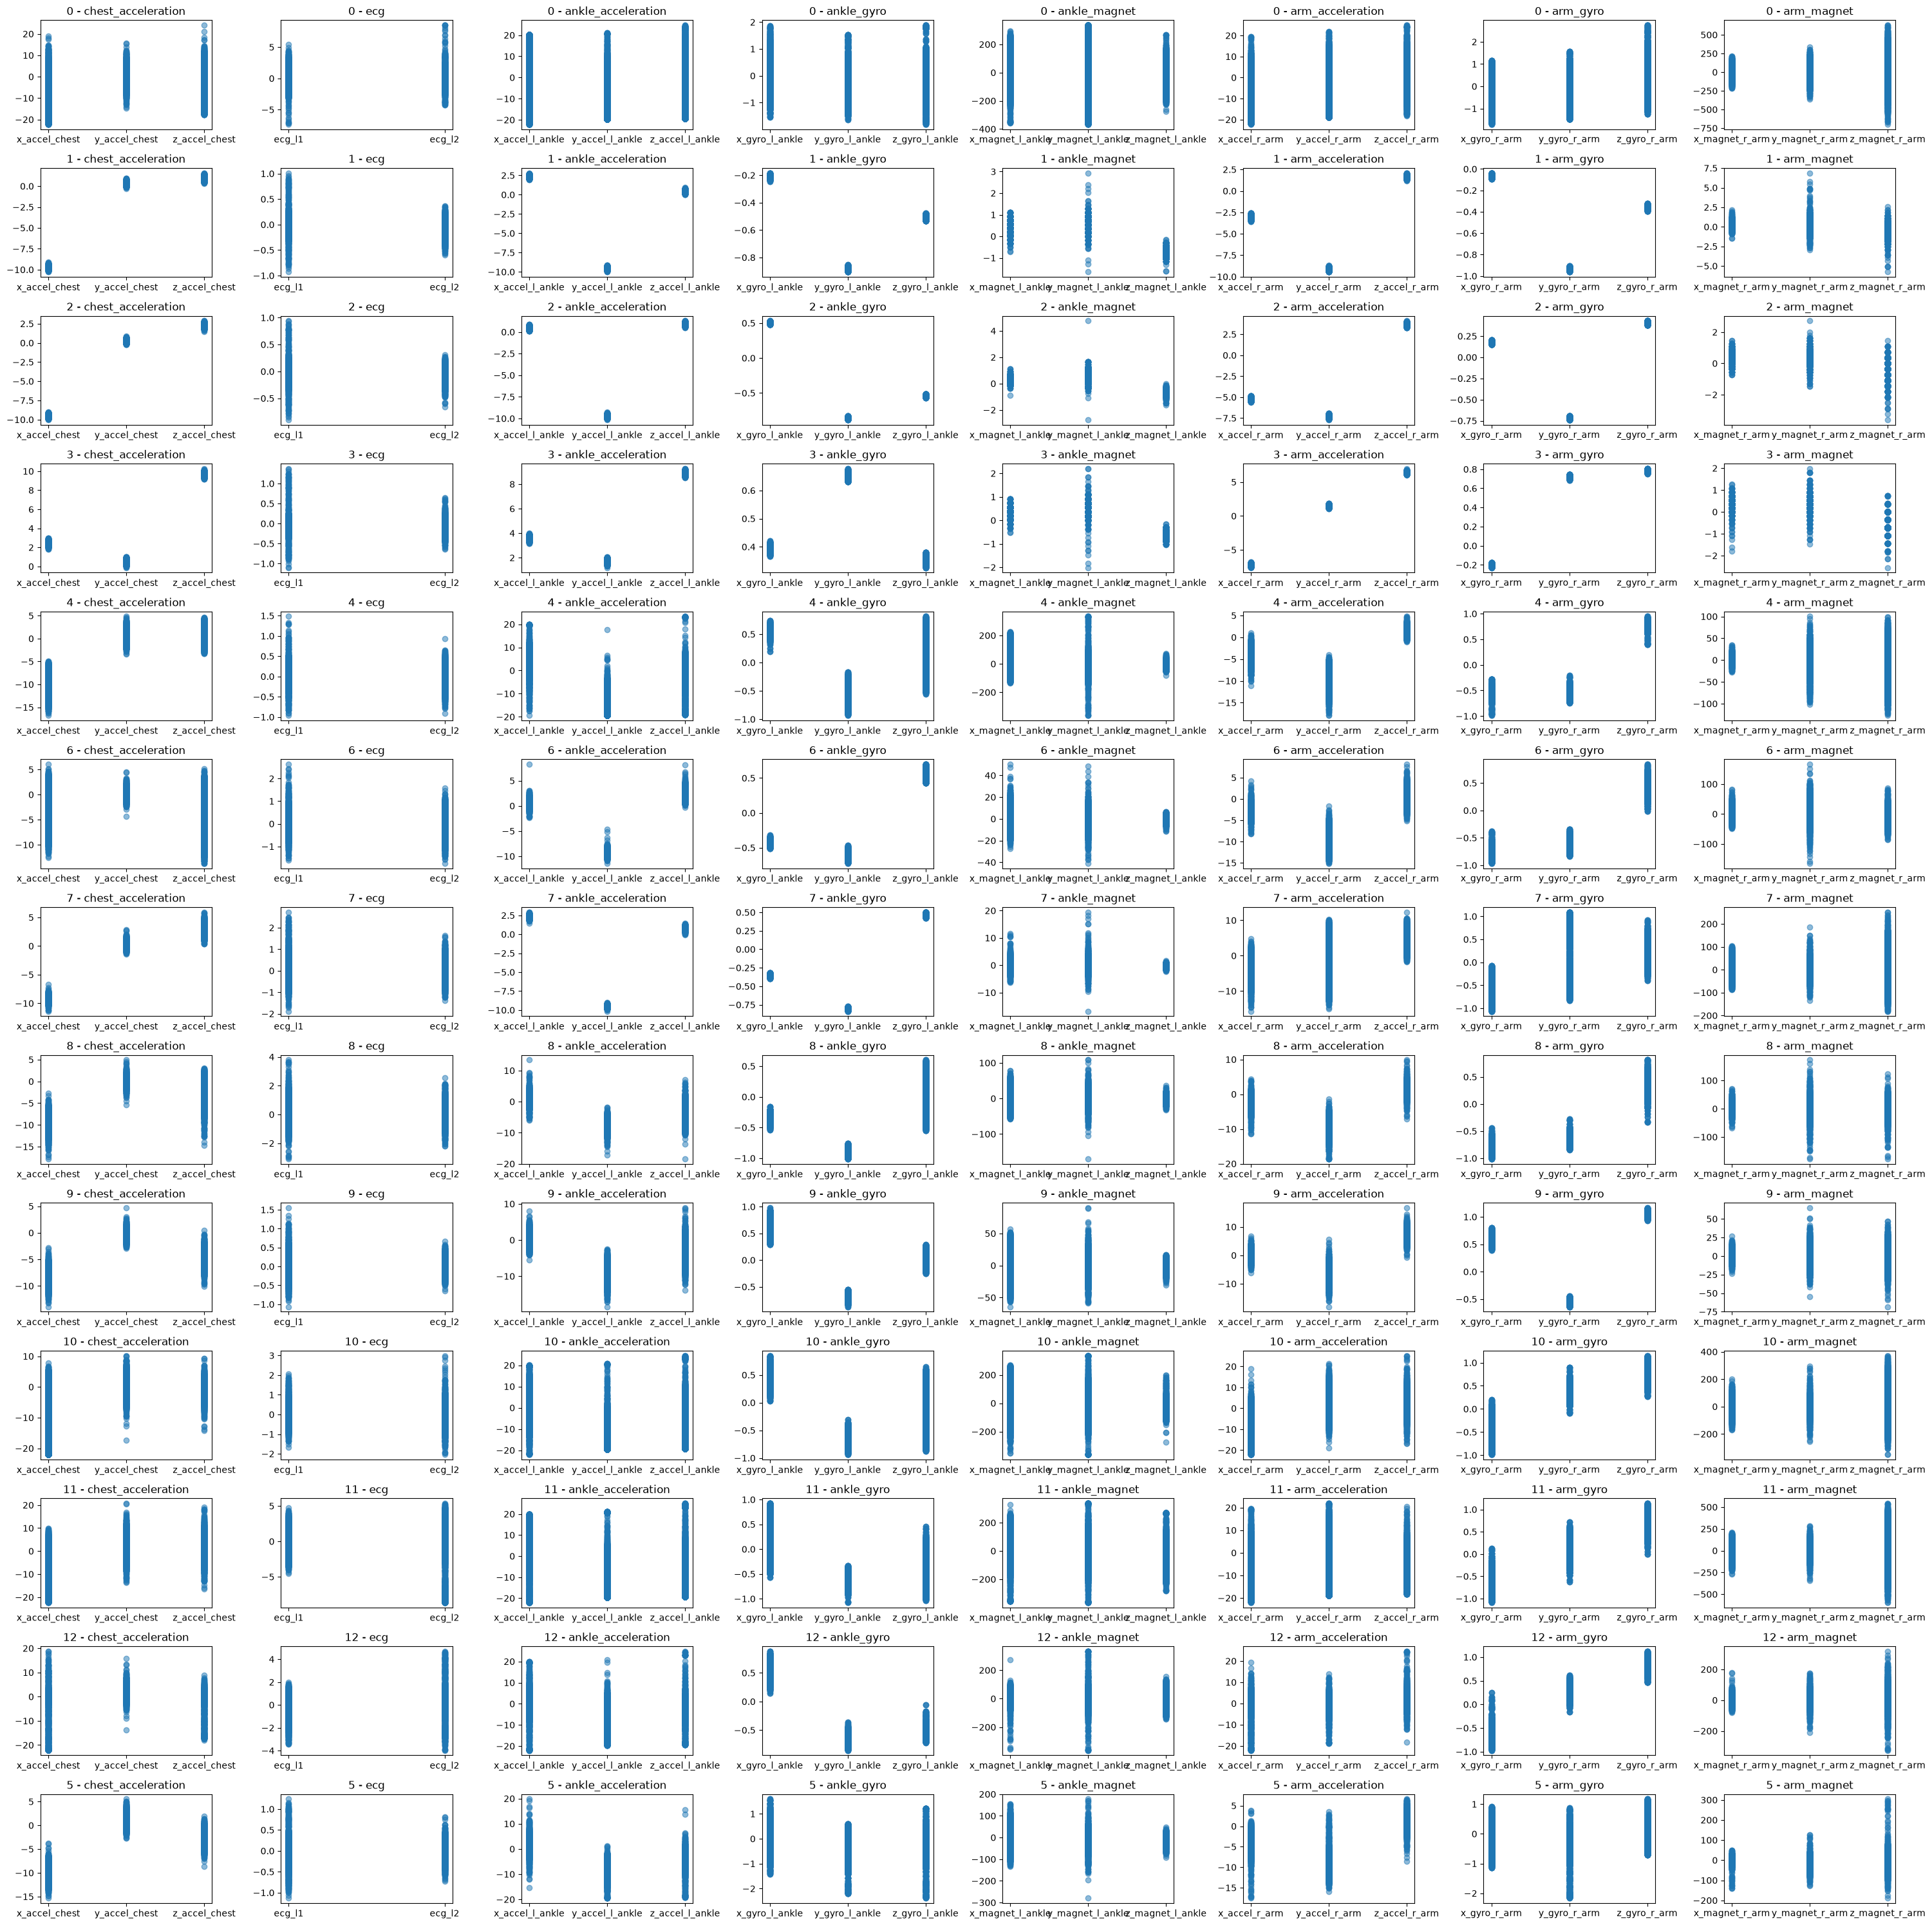

In [16]:
fig, axes = plt.subplots(
    len(subject1_df.activity_label.unique()),
    len(data_groups.keys()),
    figsize = (30, 30),
    sharex = False,
    sharey = False
)

activities = subject1_df.activity_label.unique()

for i, activity_label in enumerate(activities):
    activity_df = subject1_df[subject1_df["activity_label"] == activity_label]

    for j, group in enumerate(data_groups.keys()):
        subject_df = activity_df[list(data_groups[group])]
        data = pd.melt(subject_df, var_name = "Groups", value_name = "Values")
        axes[i, j].scatter(data["Groups"], data["Values"], alpha = 0.5)
        axes[i, j].set_title(f"{activity_label} - {group}")

plt.tight_layout()
plt.show()